# Student Placement Prediction

Problem Statement:

Develop a machine learning model to predict whether a student will be placed or
not placed based on academic and skill-related features.

In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [ ]:
# Import Dataset
df = pd.read_csv("/content/drive/MyDrive/Gen_AI_PBEL/CSV/Student_Placement_Prediction_10000.csv")
df

,CGPA,AptitudeScore,TechnicalSkills,CommunicationSkills,Internship,Attendance,PlacementStatus
0,8.02,33,5,4,Yes,58,Placed
1,8.55,99,2,10,No,52,Placed
2,4.66,57,4,9,Yes,85,Placed
3,5.59,99,7,4,No,87,Placed
4,6.03,30,3,7,No,67,Placed
...,...,...,...,...,...,...,...
9995,9.26,46,10,10,Yes,60,Placed
9996,6.23,32,1,3,Yes,80,Placed
9997,7.79,47,6,8,Yes,71,Placed
9998,8.84,62,4,3,No,100,Placed


In [ ]:
df.head()

,CGPA,AptitudeScore,TechnicalSkills,CommunicationSkills,Internship,Attendance,PlacementStatus
0,8.02,33,5,4,Yes,58,Placed
1,8.55,99,2,10,No,52,Placed
2,4.66,57,4,9,Yes,85,Placed
3,5.59,99,7,4,No,87,Placed
4,6.03,30,3,7,No,67,Placed


In [ ]:
df.tail()

,CGPA,AptitudeScore,TechnicalSkills,CommunicationSkills,Internship,Attendance,PlacementStatus
9995,9.26,46,10,10,Yes,60,Placed
9996,6.23,32,1,3,Yes,80,Placed
9997,7.79,47,6,8,Yes,71,Placed
9998,8.84,62,4,3,No,100,Placed
9999,4.69,52,3,5,Yes,85,Placed


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CGPA                 10000 non-null  float64
 1   AptitudeScore        10000 non-null  int64  
 2   TechnicalSkills      10000 non-null  int64  
 3   CommunicationSkills  10000 non-null  int64  
 4   Internship           10000 non-null  object 
 5   Attendance           10000 non-null  int64  
 6   PlacementStatus      10000 non-null  object 
dtypes: float64(1), int64(4), object(2)
memory usage: 547.0+ KB


In [ ]:
df.describe()

,CGPA,AptitudeScore,TechnicalSkills,CommunicationSkills,Attendance
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,7.234096,65.412600,5.482900,5.508600,74.775700
std,1.593633,20.519212,2.868193,2.891464,14.812398
min,4.500000,30.000000,1.000000,1.000000,50.000000
25%,5.860000,47.000000,3.000000,3.000000,62.000000
50%,7.230000,66.000000,5.000000,6.000000,75.000000
75%,8.620000,83.000000,8.000000,8.000000,88.000000
max,10.000000,100.000000,10.000000,10.000000,100.000000


In [ ]:
df.isnull().sum()

,0
CGPA,0
AptitudeScore,0
TechnicalSkills,0
CommunicationSkills,0
Internship,0
Attendance,0
PlacementStatus,0


In [ ]:
df.dropna()

,CGPA,AptitudeScore,TechnicalSkills,CommunicationSkills,Internship,Attendance,PlacementStatus
0,8.02,33,5,4,Yes,58,Placed
1,8.55,99,2,10,No,52,Placed
2,4.66,57,4,9,Yes,85,Placed
3,5.59,99,7,4,No,87,Placed
4,6.03,30,3,7,No,67,Placed
...,...,...,...,...,...,...,...
9995,9.26,46,10,10,Yes,60,Placed
9996,6.23,32,1,3,Yes,80,Placed
9997,7.79,47,6,8,Yes,71,Placed
9998,8.84,62,4,3,No,100,Placed


In [ ]:
# Mapping
df["Internship"] = df["Internship"].map({"Yes": 1 , "No": 0})
df['PlacementStatus'] = df['PlacementStatus'].map({"Placed": 1 , "Not Placed": 0})
df

,CGPA,AptitudeScore,TechnicalSkills,CommunicationSkills,Internship,Attendance,PlacementStatus
0,8.02,33,5,4,1,58,1
1,8.55,99,2,10,0,52,1
2,4.66,57,4,9,1,85,1
3,5.59,99,7,4,0,87,1
4,6.03,30,3,7,0,67,1
...,...,...,...,...,...,...,...
9995,9.26,46,10,10,1,60,1
9996,6.23,32,1,3,1,80,1
9997,7.79,47,6,8,1,71,1
9998,8.84,62,4,3,0,100,1


In [ ]:
x = df.drop(columns = ['PlacementStatus'])
y = df['PlacementStatus']
x

,CGPA,AptitudeScore,TechnicalSkills,CommunicationSkills,Internship,Attendance
0,8.02,33,5,4,1,58
1,8.55,99,2,10,0,52
2,4.66,57,4,9,1,85
3,5.59,99,7,4,0,87
4,6.03,30,3,7,0,67
...,...,...,...,...,...,...
9995,9.26,46,10,10,1,60
9996,6.23,32,1,3,1,80
9997,7.79,47,6,8,1,71
9998,8.84,62,4,3,0,100


In [ ]:
y

,PlacementStatus
0,1
1,1
2,1
3,1
4,1
...,...
9995,1
9996,1
9997,1
9998,1


In [ ]:
from os import X_OK
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)
x_train

,CGPA,AptitudeScore,TechnicalSkills,CommunicationSkills,Internship,Attendance
8856,6.99,97,10,5,1,92
1545,9.93,39,7,1,1,74
8136,9.92,44,5,4,0,63
7768,8.00,71,4,9,1,91
7782,4.99,45,1,4,1,91
...,...,...,...,...,...,...
1099,5.80,45,9,2,0,98
2514,9.04,91,9,3,0,70
6637,5.99,67,3,2,1,56
2575,5.29,39,5,4,0,69


In [ ]:
y_train

,PlacementStatus
8856,1
1545,1
8136,1
7768,1
7782,1
...,...
1099,1
2514,1
6637,1
2575,1


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

In [ ]:
# Logistic Regression
model1 = LogisticRegression()
model1.fit(X_train_scaled,y_train)
y_pred1 = model1.predict(X_test_scaled)
print ("Logistic Accuracay")
accuracy_score(y_test,y_pred1)


Logistic Accuracay


1.0

In [ ]:
# KNN
model2 = KNeighborsClassifier(n_neighbors=5)
model2.fit(X_train_scaled,y_train)
y_pred2 = model2.predict(X_test_scaled)
print ("KNN Accuracy")
accuracy_score(y_test,y_pred2)

KNN Accuracy


0.999

In [ ]:
# Decision Tree
model3 = DecisionTreeClassifier()
model3.fit(X_train_scaled,y_train)
y_pred3 = model3.predict(X_test_scaled)
print ("Decision Tree Accuracy")
accuracy_score(y_test,y_pred3)

Decision Tree Accuracy


0.9995

In [ ]:
# Random Forest
model4 = RandomForestClassifier(n_estimators=10,random_state=42)
model4.fit(X_train_scaled,y_train)
y_pred4 = model4.predict(X_test_scaled)
print ("Random Forest Accuracy")
accuracy_score(y_test,y_pred4)

Random Forest Accuracy


0.9995

In [ ]:
result = pd.DataFrame({
    "Algorithm":[
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test, y_pred1),
        accuracy_score(y_test, y_pred2),
        accuracy_score(y_test, y_pred3),
        accuracy_score(y_test, y_pred4)
    ]
})
print(result)

print("\nBest Algorithm")
print(result.loc[result["Accuracy"].idxmax()])

             Algorithm  Accuracy
0  Logistic Regression    1.0000
1                  KNN    0.9990
2        Decision Tree    0.9995
3        Random Forest    0.9995

Best Algorithm
Algorithm    Logistic Regression
Accuracy                     1.0
Name: 0, dtype: object


In [ ]:
print(confusion_matrix(y_test, y_pred4))
print(classification_report(y_test, y_pred4))

[[   0    1]
 [   0 1999]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00      1999

    accuracy                           1.00      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       1.00      1.00      1.00      2000



# Loan Approval Prediction

Problem Statement:

Build a machine learning model to predict whether a loan application will be
approved or rejected based on customer details.

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/Gen_AI_PBEL/CSV/LoanApprovalPrediction.csv")
data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
593,LP002978,Female,No,0.0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
594,LP002979,Male,Yes,3.0,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
595,LP002983,Male,Yes,1.0,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
596,LP002984,Male,Yes,2.0,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [ ]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
data.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
593,LP002978,Female,No,0.0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
594,LP002979,Male,Yes,3.0,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
595,LP002983,Male,Yes,1.0,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
596,LP002984,Male,Yes,2.0,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
597,LP002990,Female,No,0.0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            598 non-null    object 
 1   Gender             598 non-null    object 
 2   Married            598 non-null    object 
 3   Dependents         586 non-null    float64
 4   Education          598 non-null    object 
 5   Self_Employed      598 non-null    object 
 6   ApplicantIncome    598 non-null    int64  
 7   CoapplicantIncome  598 non-null    float64
 8   LoanAmount         577 non-null    float64
 9   Loan_Amount_Term   584 non-null    float64
 10  Credit_History     549 non-null    float64
 11  Property_Area      598 non-null    object 
 12  Loan_Status        598 non-null    object 
dtypes: float64(5), int64(1), object(7)
memory usage: 60.9+ KB


In [ ]:
data.describe()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,586.000000,598.000000,598.000000,577.000000,584.000000,549.000000
mean,0.755973,5292.252508,1631.499866,144.968804,341.917808,0.843352
std,1.007751,5807.265364,2953.315785,82.704182,65.205994,0.363800
min,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000
25%,0.000000,2877.500000,0.000000,100.000000,360.000000,1.000000
50%,0.000000,3806.000000,1211.500000,127.000000,360.000000,1.000000
75%,1.750000,5746.000000,2324.000000,167.000000,360.000000,1.000000
max,3.000000,81000.000000,41667.000000,650.000000,480.000000,1.000000


In [ ]:
data.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,12
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,21
Loan_Amount_Term,14


In [ ]:
data.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
593,False
594,False
595,False
596,False


In [ ]:
# Dropping Loan_ID column
data.drop(['Loan_ID'],axis=1,inplace=True)
data

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
593,Female,No,0.0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
594,Male,Yes,3.0,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
595,Male,Yes,1.0,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
596,Male,Yes,2.0,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [ ]:
data['Gender'].fillna(data['Gender'].mode()[0], inplace=True)
data['Married'].fillna(data['Married'].mode()[0], inplace=True)
data['Dependents'].fillna(data['Dependents'].mode()[0], inplace=True)
data['Self_Employed'].fillna(data['Self_Employed'].mode()[0], inplace=True)
data['Credit_History'].fillna(data['Credit_History'].mode()[0], inplace=True)

# Fill numerical missing values

data['LoanAmount'].fillna(data['LoanAmount'].median(), inplace=True)
data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].median(), inplace=True)

In [ ]:
LE = LabelEncoder()

for column in data.columns:
    if data[column].dtype == 'object':
        data[column] = LE.fit_transform(data[column])

In [ ]:
data

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0.0,0,0,5849,0.0,127.0,360.0,1.0,2,1
1,1,1,1.0,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0.0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0.0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0.0,0,0,6000,0.0,141.0,360.0,1.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
593,0,0,0.0,0,0,2900,0.0,71.0,360.0,1.0,0,1
594,1,1,3.0,0,0,4106,0.0,40.0,180.0,1.0,0,1
595,1,1,1.0,0,0,8072,240.0,253.0,360.0,1.0,2,1
596,1,1,2.0,0,0,7583,0.0,187.0,360.0,1.0,2,1


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             598 non-null    int64  
 1   Married            598 non-null    int64  
 2   Dependents         598 non-null    float64
 3   Education          598 non-null    int64  
 4   Self_Employed      598 non-null    int64  
 5   ApplicantIncome    598 non-null    int64  
 6   CoapplicantIncome  598 non-null    float64
 7   LoanAmount         598 non-null    float64
 8   Loan_Amount_Term   598 non-null    float64
 9   Credit_History     598 non-null    float64
 10  Property_Area      598 non-null    int64  
 11  Loan_Status        598 non-null    int64  
dtypes: float64(5), int64(7)
memory usage: 56.2 KB


In [ ]:
X = data.drop("Loan_Status", axis=1)
y = data["Loan_Status"]

In [ ]:
X

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,1,0,0.0,0,0,5849,0.0,127.0,360.0,1.0,2
1,1,1,1.0,0,0,4583,1508.0,128.0,360.0,1.0,0
2,1,1,0.0,0,1,3000,0.0,66.0,360.0,1.0,2
3,1,1,0.0,1,0,2583,2358.0,120.0,360.0,1.0,2
4,1,0,0.0,0,0,6000,0.0,141.0,360.0,1.0,2
...,...,...,...,...,...,...,...,...,...,...,...
593,0,0,0.0,0,0,2900,0.0,71.0,360.0,1.0,0
594,1,1,3.0,0,0,4106,0.0,40.0,180.0,1.0,0
595,1,1,1.0,0,0,8072,240.0,253.0,360.0,1.0,2
596,1,1,2.0,0,0,7583,0.0,187.0,360.0,1.0,2


In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.2,random_state=42)

In [ ]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy:
0.8166666666666667


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:")
print(accuracy_score(y_test, y_pred_knn))

KNN Accuracy:
0.775


In [ ]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:")
print(accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy:
0.7


In [ ]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:")
print(accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy:
0.8083333333333333


In [ ]:
accuracy = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy":[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_knn),
        accuracy_score(y_test,y_pred_dt),
        accuracy_score(y_test,y_pred_rf)
    ]
})

print(accuracy)

                 Model  Accuracy
0  Logistic Regression  0.816667
1                  KNN  0.775000
2        Decision Tree  0.700000
3        Random Forest  0.808333


In [ ]:
best = accuracy.loc[accuracy['Accuracy'].idxmax()]
print(best)

Model       Logistic Regression
Accuracy               0.816667
Name: 0, dtype: object


              precision    recall  f1-score   support

           0       0.80      0.46      0.58        35
           1       0.81      0.95      0.88        85

    accuracy                           0.81       120
   macro avg       0.81      0.71      0.73       120
weighted avg       0.81      0.81      0.79       120



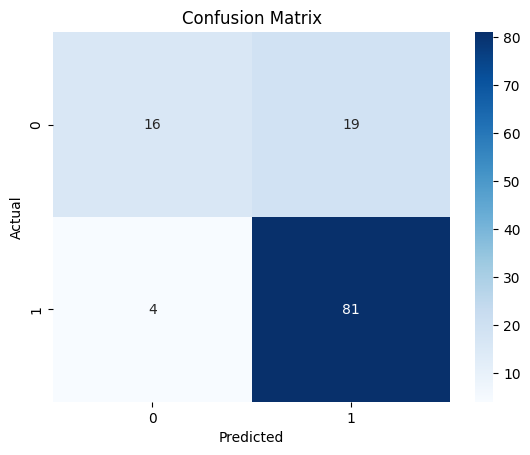

In [ ]:
print(classification_report(y_test, y_pred_rf))
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

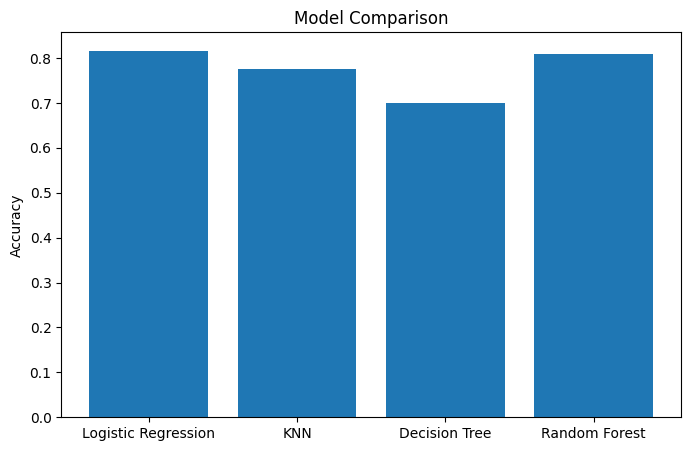

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(accuracy['Model'], accuracy['Accuracy'])
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()